# 3D Computer Vision Laboratory — Depth from Stereo Disparity

In this notebook we recover a **depth map** of a scene from a pair of stereo images, using classical **block matching**.

**Pipeline**
1. Load a *rectified* stereo pair (left/right images where corresponding scene points fall on the same image row).
2. For every pixel, search along its row in the other image for the most similar patch — the horizontal shift that gives the best match is the **disparity**.
3. Convert disparity to metric **depth** with the stereo triangulation formula.
4. Visualize the result as a 3D point cloud.

> **Rectification assumption.** Thanks to *epipolar geometry*, once two images are rectified, the projections of any 3D point fall on the **same row** in both images. This is what lets us search for correspondences along a single line instead of the whole 2D image.

## 1. Dataset

We use the **Art** scene from the [Middlebury 2005 stereo dataset](https://vision.middlebury.edu/stereo/data/scenes2005/), a standard benchmark for stereo algorithms. The archive contains the rectified left/right image pair (`view1.png`, `view5.png`).

In [1]:
# If running outside Colab and any package is missing, uncomment:
# !pip install opencv-python numpy matplotlib numba plotly

import os
import urllib.request
import zipfile

DATA_URL = "https://vision.middlebury.edu/stereo/data/scenes2005/FullSize/zip-2views/Art-2views.zip"
ZIP_PATH = "Art-2views.zip"
DATA_DIR = "Art"

if not os.path.isdir(DATA_DIR):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(".")
    print("Done.")
else:
    print("Dataset already present, skipping download.")


Dataset already present, skipping download.


## 2. Imports

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

## 3. Loading the stereo pair

We load both views and convert them to grayscale — block matching only needs pixel intensities, and a single channel is cheaper to work with.

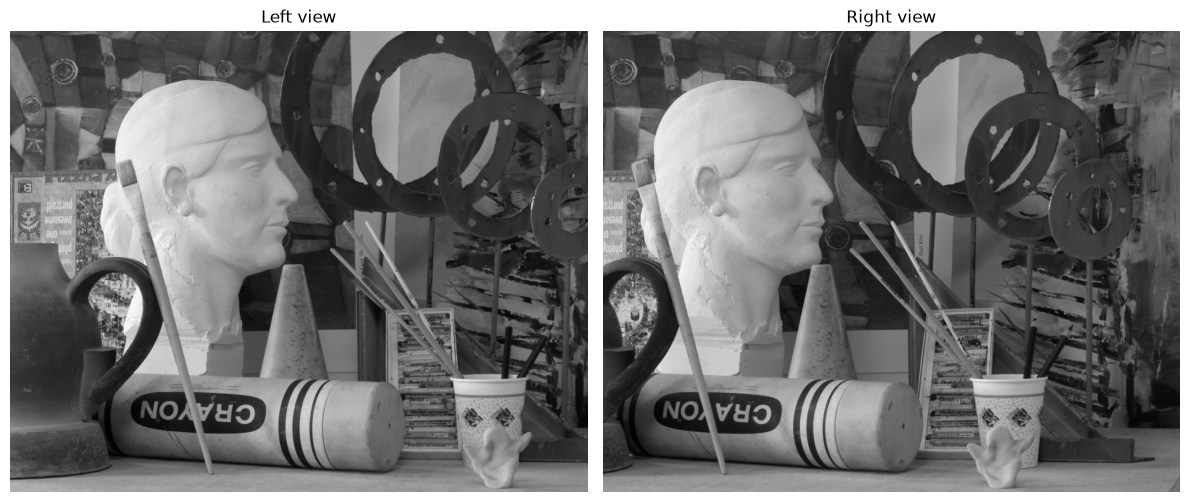

In [6]:
img_left_color = cv2.imread("Art/view1.png")
img_right_color = cv2.imread("Art/view5.png")

img_left = cv2.cvtColor(img_left_color, cv2.COLOR_BGR2GRAY)
img_right = cv2.cvtColor(img_right_color, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_left, cmap="gray");  axes[0].set_title("Left view");  axes[0].axis("off")
axes[1].imshow(img_right, cmap="gray"); axes[1].set_title("Right view"); axes[1].axis("off")
plt.tight_layout()
plt.show()


Notice how objects shift horizontally between the two views — nearby objects shift more than distant ones. That shift is exactly what we are about to measure.

### Tip: downscale while experimenting

Block matching costs roughly $O(\text{pixels} \times \text{max\_disparity} \times \text{kernel\_size}^2)$ — full resolution can be slow to iterate on. Lower `DOWNSCALE` for faster experiments, then set it to `1.0` for your final, highest-detail run.

In [7]:
DOWNSCALE = 0.5  # 1.0 = full resolution

if DOWNSCALE != 1.0:
    new_size = (int(img_left.shape[1] * DOWNSCALE), int(img_left.shape[0] * DOWNSCALE))
    img_left = cv2.resize(img_left, new_size, interpolation=cv2.INTER_AREA)
    img_right = cv2.resize(img_right, new_size, interpolation=cv2.INTER_AREA)
    img_left_color = cv2.resize(img_left_color, new_size, interpolation=cv2.INTER_AREA)

print("Working resolution:", img_left.shape)


Working resolution: (555, 695)


## 4. Disparity via block matching

**Idea.** For a pixel $(row, col)$ in the left image, take a small $k \times k$ patch (block) around it. Slide a same-sized patch along the *same row* in the right image and find the horizontal offset — the **disparity** $d$ — that makes the two patches most similar:

$$
d^{*}(row,col) = \underset{0 \le d < D_{max}}{\mathrm{argmin}} \;\; \mathrm{SAD}\big(B_L(row,col),\; B_R(row,\,col-d)\big)
$$

with the **Sum of Absolute Differences (SAD)**:

$$
\mathrm{SAD}(B_L, B_R) = \sum_{i,j} \big| B_L(i,j) - B_R(i,j) \big|
$$

SAD is $0$ for identical patches and grows as patches become less alike, so smaller is better. We only search **to the left** ($col - d$): given this camera arrangement (left camera to the left of the right one), a scene point's column in the left image is always $\geq$ its column in the right image.

Two parameters trade off quality against speed:
- `kernel_size` — larger blocks are more robust to noise but blur disparity edges (and cost more to evaluate).
- `max_disparity` — the search range; must be large enough to cover the closest objects in the scene, or their disparity will be clipped.

A plain Python double loop over every pixel and every candidate disparity is far too slow, so we JIT-compile it with `numba`.

In [9]:
@njit
def compute_block_sad(left_block, right_block):
    """
    Sum of Absolute Differences (SAD) between two equally-sized patches.
    Lower value = more similar.
    """
    return np.sum(np.abs(left_block.astype(np.float64) - right_block.astype(np.float64)))


@njit
def compute_disparity_loop(img_left, img_right, kernel_size, max_disparity):
    """
    For every pixel of the left image, find the disparity d (0 <= d < max_disparity)
    whose right-image block best matches the left block, searching along the row.
    """
    height, width = img_left.shape
    disparity_map = np.zeros((height, width), dtype=np.uint8)
    offset = kernel_size // 2

    for row in range(offset, height - offset):
        for col in range(offset, width - offset):
            best_score = np.inf
            best_disp = 0

            left_block = img_left[row - offset:row + offset + 1, col - offset:col + offset + 1]

            for d in range(max_disparity):
                col_r = col - d
                if col_r - offset < 0:
                    break  # right block would fall outside the image

                right_block = img_right[row - offset:row + offset + 1,
                                         col_r - offset:col_r + offset + 1]

                sad = compute_block_sad(left_block, right_block)
                if sad < best_score:
                    best_score = sad
                    best_disp = d

            disparity_map[row, col] = best_disp

    return disparity_map


def compute_disparity_map(img_left, img_right, kernel_size=9, max_disparity=100):
    """
    Computes a disparity map for a rectified grayscale stereo pair.
    """
    return compute_disparity_loop(img_left, img_right, kernel_size, max_disparity)


## 5. Running block matching

The first call includes a one-time Numba compilation cost; subsequent calls with the same argument types are fast. Runtime scales with `max_disparity` and `kernel_size**2` — reduce `DOWNSCALE` above if this is too slow on your machine.

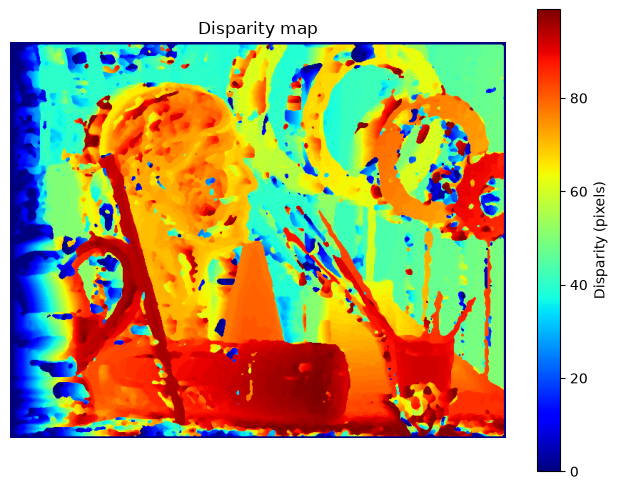

In [10]:
disp = compute_disparity_map(img_left, img_right, kernel_size=7, max_disparity=100)

# Optional post-processing: median blur removes isolated mismatches ("salt & pepper" noise)
disp_filtered = cv2.medianBlur(disp, 5)

plt.figure(figsize=(8, 6))
plt.imshow(disp_filtered, cmap="jet")
plt.colorbar(label="Disparity (pixels)")
plt.title("Disparity map")
plt.axis("off")
plt.show()


### Sanity check: comparing against the ground truth

The Middlebury dataset ships a ground-truth disparity map (`disp1.png`) for the left view, so we can check how close our block-matching estimate is to the true answer.

Pixel values in `disp1.png` are not the disparity directly: since true disparities in this scene are large, Middlebury stores `disparity - DMIN` (a plain 8-bit PNG can't hold values above 255) and reserves `0` for "unknown". `DMIN` for this scene is given in `Art/dmin.txt`. We add it back, then rescale by `DOWNSCALE` — exactly like the focal length below — since disparity shrinks/grows proportionally with image size.

If the estimated and ground-truth ranges look nothing alike (e.g. the estimate is pinned near `max_disparity`), that's a sign `max_disparity` is too small to cover this scene's true disparities.

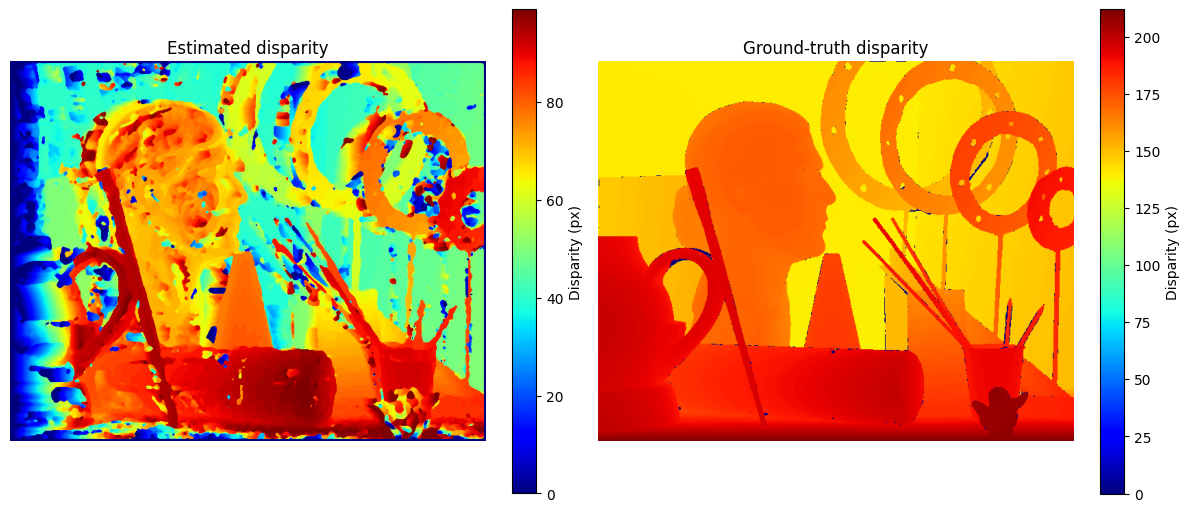

In [ ]:
DMIN = 200  # from Art/dmin.txt

def load_ground_truth_disparity(path, dmin, scale=1.0):
    """
    Loads a Middlebury ground-truth disparity map, decoded to true disparity
    (in pixels) at the given working resolution. Pixel value 0 = unknown.
    """
    gt_raw = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    valid = gt_raw > 0
    gt_disp = np.zeros_like(gt_raw, dtype=np.float32)
    gt_disp[valid] = gt_raw[valid].astype(np.float32) + dmin

    if scale != 1.0:
        new_size = (int(gt_disp.shape[1] * scale), int(gt_disp.shape[0] * scale))
        gt_disp = cv2.resize(gt_disp, new_size, interpolation=cv2.INTER_NEAREST) * scale

    return gt_disp

disp_gt = load_ground_truth_disparity("Art/disp1.png", dmin=DMIN, scale=DOWNSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(disp_filtered, cmap="jet"); axes[0].set_title("Estimated disparity"); axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="Disparity (px)")
im1 = axes[1].imshow(disp_gt, cmap="jet"); axes[1].set_title("Ground-truth disparity"); axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="Disparity (px)")
plt.tight_layout()
plt.show()

# --- Pick which disparity map feeds the depth map and 3D view below ---
disp_filtered = disp_filtered   # use the estimated disparity (default)
#disp_filtered = disp_gt       # uncomment to use the ground truth instead


## 6. From disparity to depth

For a rectified pinhole stereo pair with focal length $f$ (in pixels) and baseline $B$ (distance between camera centers), similar triangles give:

$$
Z = \frac{f \cdot B}{d}
$$

Larger disparity means closer to the camera; $d = 0$ is undefined (a point at infinity) and is treated as invalid.

For the Middlebury *Art* scene (full-size calibration): $f = 3740$ px, $B = 160$ mm. Because we may have downscaled the images, we rescale $f$ by `DOWNSCALE` to match the working resolution.

In [ ]:
FOCAL_LENGTH_PX = 3740.0  # at full resolution
BASELINE_MM = 160.0

def disparity_to_depth(disp_map, focal_length=FOCAL_LENGTH_PX, baseline=BASELINE_MM):
    """
    Converts a disparity map (pixels) to a depth map (millimeters): Z = f * B / d
    """
    disp_f = disp_map.astype(np.float32)
    with np.errstate(divide="ignore", invalid="ignore"):
        depth_map = (focal_length * baseline) / disp_f
    depth_map[disp_f == 0] = 0.0  # undefined depth
    return depth_map

# The focal length is defined at full resolution; rescale it if we downscaled the images.
effective_focal_length = FOCAL_LENGTH_PX * DOWNSCALE
depth_map = disparity_to_depth(disp_filtered, focal_length=effective_focal_length)


## 7. 3D visualization

We project each pixel to $(x, y, Z)$ using its image coordinates and estimated depth, and color it with the original image color, giving a rough 3D point cloud of the scene.

In [11]:
import plotly.graph_objects as go

def plot_depth_map_3d(depth_map, img_color_bgr, step=4, max_depth_percentile=85):
    """
    Renders a depth map as a colored 3D point cloud.

    Near-zero disparities map to very large Z (Z = f*B/d), so a small number of
    far-away/noisy points can dominate the z-range and flatten the rest of the
    cloud. Points beyond `max_depth_percentile` of the valid depth distribution
    are dropped before plotting; set it to None to disable filtering.
    """
    depth_ds = depth_map[::step, ::step]
    img_ds = cv2.cvtColor(img_color_bgr, cv2.COLOR_BGR2RGB)[::step, ::step, :]

    h, w = depth_ds.shape
    xs, ys = np.meshgrid(np.arange(w), np.arange(h))
    xs, ys, zs = xs.flatten(), ys.flatten(), depth_ds.flatten()
    colors = img_ds.reshape(-1, 3)

    valid = zs > 0
    if max_depth_percentile is not None:
        max_depth = np.percentile(zs[valid], max_depth_percentile)
        valid &= zs <= max_depth
    xs, ys, zs, colors = xs[valid], ys[valid], zs[valid], colors[valid]
    color_strings = [f"rgb({r},{g},{b})" for r, g, b in colors]

    fig = go.Figure(data=[go.Scatter3d(
        x=xs, y=ys, z=zs, mode="markers",
        marker=dict(size=2, color=color_strings, opacity=0.8),
    )])
    fig.update_layout(
        title="3D reconstruction from stereo disparity",
        scene=dict(xaxis_title="x (px)", yaxis_title="y (px)", zaxis_title="depth Z (mm)"),
    )
    fig.show()

plot_depth_map_3d(depth_map, img_left_color, step=4)


ModuleNotFoundError: No module named 'plotly'

## 8. Limitations of simple block matching

- **Textureless regions** (e.g. blank walls) give many equally good matches → noisy or arbitrary disparities.
- **Occlusions**: pixels visible in only one image have no correct match at all.
- **Repetitive patterns** can cause the wrong local minimum to be picked (ambiguous matches).
- The block size trades off **detail vs. robustness** — there is no single best value for every scene.

More advanced methods (semi-global matching, learned cost volumes, left-right consistency checks, ...) address these issues, but they all build on the same core idea: find corresponding points between views, then triangulate.

You can check out the **OpenCV** implementation of calculating disparity maps: https://docs.opencv.org/4.10.0/dd/d53/tutorial_py_depthmap.html